In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# carregar o dataset
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
titanic = pd.read_csv(url)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# verificar o tipo dos atributos
titanic.dtypes

survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

In [6]:
# quantidade de instâncias
print(f"Instâncias: {titanic.shape[0]}")
print(f"Atributos: {titanic.shape[1]}")

Instâncias: 891
Atributos: 15


In [7]:
# descrever estaticamente os dados numéricos
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# descrever estaticamente dados categóricos
titanic.describe(include=['O'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [17]:
moda_categorica = titanic[['sex', 'embarked', 'class']].mode()
moda_categorica

,sex,embarked,class
0,male,S,Third


#### Limpeza dos dados

In [18]:
# exibir informações iniciais para verificar a quantidade de itens faltantes
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [ ]:
# Coluna 'deck' tem apenas 203 entradas não-nulas. Isto é um indício para remoção
titanic.drop('deck', axis=1, inplace=True)
# titanic

# coluna fare (tarifa) pode ser reduzida de tamanho (float64 para float62) para ocupar menos memória
titanic['fare'] = titanic['fare'].astype(np.float32)
titanic.info()


#### Tratamento de dados faltantes e duplicados

In [24]:
# são 177 dados faltantes (NaN - not a number)
titanic[titanic['age'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.458300,Q,Third,man,True,NaN,Queenstown,no,True
17,1,2,male,NaN,0,0,13.000000,S,Second,man,True,NaN,Southampton,yes,True
19,1,3,female,NaN,0,0,7.225000,C,Third,woman,False,NaN,Cherbourg,yes,True
26,0,3,male,NaN,0,0,7.225000,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.879200,Q,Third,woman,False,NaN,Queenstown,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.229200,C,Third,man,True,NaN,Cherbourg,no,True
863,0,3,female,NaN,8,2,69.550003,S,Third,woman,False,NaN,Southampton,no,False
868,0,3,male,NaN,0,0,9.500000,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.895800,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# substituir dados faltantes da idade pela média das outras idades
titanic['age'].fillna(titanic['age'].mean(), inplace=True)

In [30]:
# mostrar os dados faltantes, após a inserção das médias das idades
titanic[titanic['age'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


In [33]:
# Dados faltantes da coluna 'embarked'. Apenas duas instâncias apresentam NaN.
titanic[titanic['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True


In [43]:
# porto mais usado através da métrica moda
porto_mais_usado = titanic['embarked'].mode()[0]
print(f" Porto mais usado: {porto_mais_usado}")

 Porto mais usado: S


In [ ]:
# substituir dados faltantes da coluna 'embarked'
titanic['embarked'].fillna(porto_mais_usado, inplace=True)

In [46]:
# verificação da coluna 'embarked' pós-tratamento
titanic[titanic['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


In [49]:
# remoção de duplicadas - 111 instâncias apareceram nos dados
titanic[titanic.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
47,1,3,female,29.699118,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True
76,0,3,male,29.699118,0,0,7.8958,S,Third,man,True,Southampton,no,True
77,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
87,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
95,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.000000,0,0,7.8958,S,Third,man,True,Southampton,no,True
877,0,3,male,19.000000,0,0,7.8958,S,Third,man,True,Southampton,no,True
878,0,3,male,29.699118,0,0,7.8958,S,Third,man,True,Southampton,no,True
884,0,3,male,25.000000,0,0,7.0500,S,Third,man,True,Southampton,no,True


In [50]:
# remover duplicadas
titanic.drop_duplicates(inplace=True)

In [58]:
# verificando o dataset após remoção de duplicadas - 780 instâncias
print(f" Instâncias: {titanic.shape[0]}")

 Instâncias: 780


#### Análise de correlação entre variáveis e proporções

In [6]:
plt.suptitle("Gráfico de calor das variáveis numéricas")
dados_numericos = titanic.select_dtypes(include=['int', 'float', 'bool'])
print(dados_numericos)

     survived  pclass   age  sibsp  parch     fare  adult_male  alone
0           0       3  22.0      1      0   7.2500        True  False
1           1       1  38.0      1      0  71.2833       False  False
2           1       3  26.0      0      0   7.9250       False   True
3           1       1  35.0      1      0  53.1000       False  False
4           0       3  35.0      0      0   8.0500        True   True
..        ...     ...   ...    ...    ...      ...         ...    ...
886         0       2  27.0      0      0  13.0000        True   True
887         1       1  19.0      0      0  30.0000       False   True
888         0       3   NaN      1      2  23.4500       False  False
889         1       1  26.0      0      0  30.0000        True   True
890         0       3  32.0      0      0   7.7500        True   True

[891 rows x 8 columns]


<Figure size 640x480 with 0 Axes>

<Axes: >

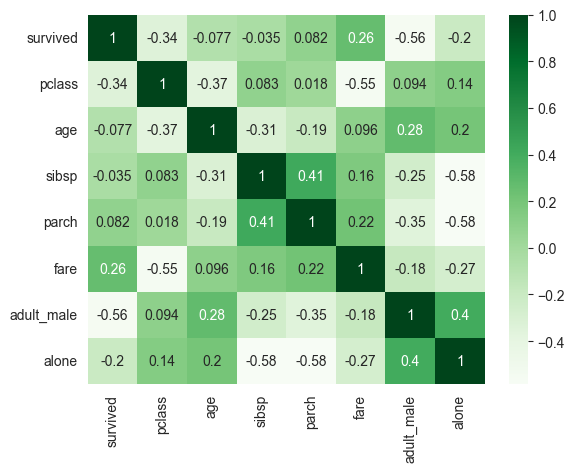

In [7]:
# plotando o gráfico de calor através da funçao heatmap do seaborn
sns.heatmap(dados_numericos.corr(), annot=True, cmap="Greens")

In [33]:
# fazendo filtros
homens = titanic.loc[titanic['sex'] == 'male', 'survived']
# print(homens)

total_homens = homens.count()
print(f"Total de homens: {total_homens}\n")

(homens.value_counts()/total_homens)*100

print(homens.value_counts())

Total de homens: 577

survived
0    468
1    109
Name: count, dtype: int64


In [40]:
mulheres = titanic.loc[titanic['sex'] == 'female', 'survived']
print(mulheres)
print(mulheres.value_counts())
total_mulheres = mulheres.count()
print(total_mulheres)

1      1
2      1
3      1
8      1
9      1
      ..
880    1
882    0
885    0
887    1
888    0
Name: survived, Length: 314, dtype: int64
survived
1    233
0     81
Name: count, dtype: int64
314


In [43]:
# porcentagem de mulheres que sobreviveram
(mulheres.value_counts()/total_mulheres) * 100

survived
1    74.203822
0    25.796178
Name: count, dtype: float64

In [51]:
# porcentagem de adultos que sobreviveram

adultos = titanic.loc[titanic['age'] > 17, 'survived']
print(adultos.value_counts())

survived
0    372
1    229
Name: count, dtype: int64


In [68]:
# Adultos em % que sobreviram - 61, 89%
print(f" Total de adultos (maior de 17 anos): {adultos.count()}")
round((adultos.value_counts()/adultos.count()) * 100, 2)


 Total de adultos (maior de 17 anos): 601


survived
0    61.9
1    38.1
Name: count, dtype: float64

In [70]:
# porcentagem de crianças que sobreviveram

criancas = titanic.loc[titanic['age'] < 17, 'survived']
print(criancas.value_counts())

survived
1    55
0    45
Name: count, dtype: int64


In [74]:
round(criancas.value_counts()/criancas.count() * 100, 2)

survived
1    55.0
0    45.0
Name: count, dtype: float64

In [88]:
# Total de pessoas da primeira classe que sobreviveram
totalclasse1 = titanic.loc[titanic['pclass'] == 1, 'survived'].count()
print(totalclasse1)
titanic.loc[titanic['pclass'] == 1, 'survived'].value_counts() / totalclasse1 * 100

216


survived
1    62.962963
0    37.037037
Name: count, dtype: float64

In [89]:
# Total de pessoas da segunda classe que sobreviveram
totalclasse2 = titanic.loc[titanic['pclass'] == 2, 'survived'].count()
print(totalclasse2)
titanic.loc[titanic['pclass'] == 2, 'survived'].value_counts() / totalclasse2 * 100

184


survived
0    52.717391
1    47.282609
Name: count, dtype: float64

In [90]:
# Total de pessoas da terceira classe que sobreviveram
totalclasse3 = titanic.loc[titanic['pclass'] == 3, 'survived'].count()
print(totalclasse3)
titanic.loc[titanic['pclass'] == 3, 'survived'].value_counts() / totalclasse3 * 100

491


survived
0    75.763747
1    24.236253
Name: count, dtype: float64

#### Tabelas dinâmicas/pivô

In [99]:
tabela_pivo_classe = pd.pivot_table(titanic, values='survived', index='class', aggfunc='mean')
display(tabela_pivo_classe)

,survived
class,
First,0.629630
Second,0.472826
Third,0.242363


In [100]:
tabela_pivo_sexo = pd.pivot_table(titanic, values='survived', index='sex', aggfunc='mean')
display(tabela_pivo_sexo)

,survived
sex,
female,0.742038
male,0.188908


In [101]:
tabela_pivo_portao_embarque = pd.pivot_table(titanic, values='survived', index='embarked', aggfunc='mean')
display(tabela_pivo_portao_embarque)

,survived
embarked,
C,0.553571
Q,0.389610
S,0.336957


#### Gráficos

##### Análise de sobreviventes x idade

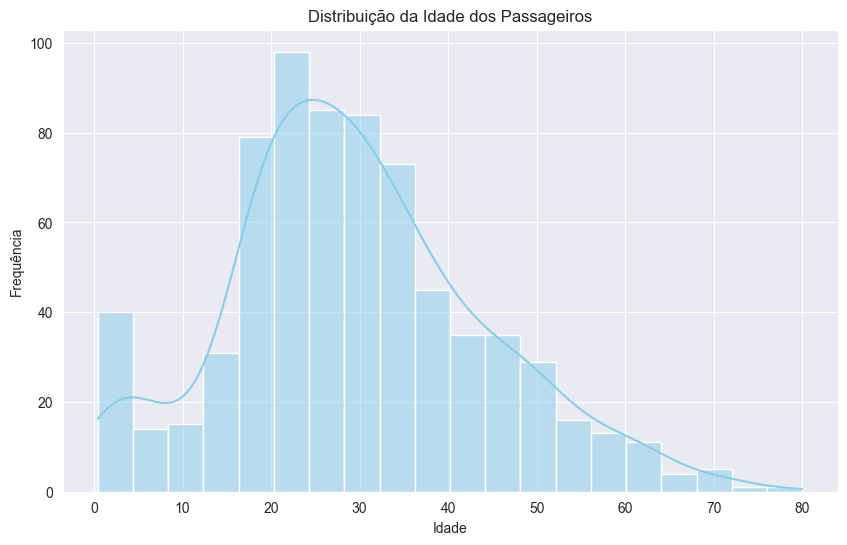

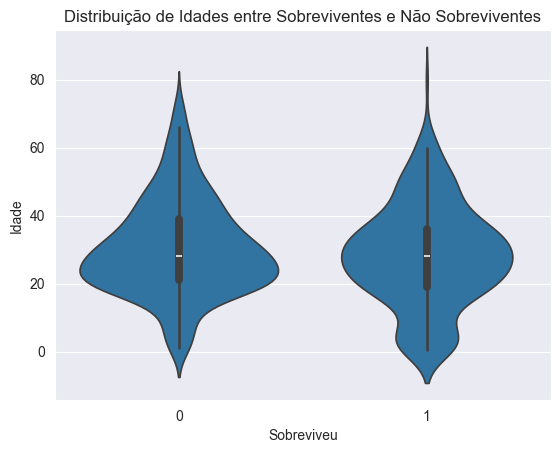

In [103]:
# Distribuição da Idade
plt.figure(figsize=(10, 6))
sns.histplot(titanic['age'].dropna(), kde=True, color="skyblue")
plt.title('Distribuição da Idade dos Passageiros')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

sns.violinplot(x='survived', y='age', data=titanic)
plt.title('Distribuição de Idades entre Sobreviventes e Não Sobreviventes')
plt.xlabel('Sobreviveu')
plt.ylabel('Idade')
plt.show()

##### Análise da tarifa paga

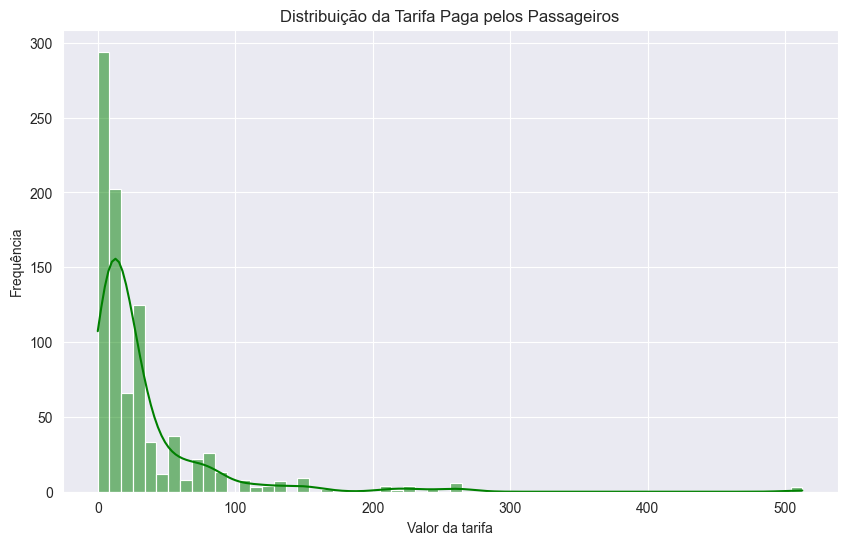

In [106]:
# Distribuição da Tarifa
plt.figure(figsize=(10, 6))
sns.histplot(titanic['fare'], kde=True, color="green")
plt.title('Distribuição da Tarifa Paga pelos Passageiros')
plt.xlabel('Valor da tarifa')
plt.ylabel('Frequência')
plt.show()

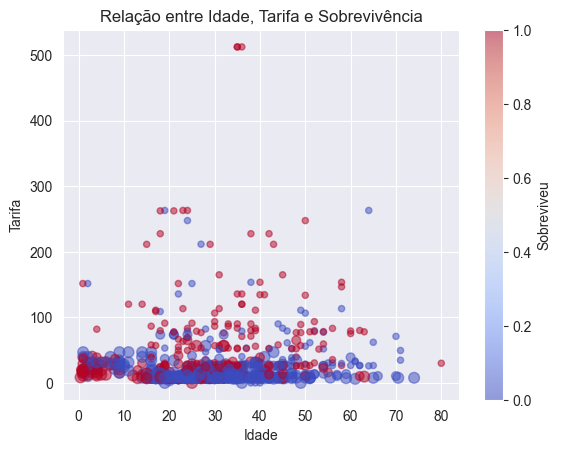

In [107]:
# Relação entre idade, tarifa e sobrevivência
plt.scatter(titanic['age'], titanic['fare'], alpha=0.5,
            s=titanic['pclass']*20,  # Tamanho do ponto baseado em pclass
            c=titanic['survived'], cmap='coolwarm')  # Cor baseada na sobrevivência
plt.colorbar(label='Sobreviveu')
plt.title('Relação entre Idade, Tarifa e Sobrevivência')
plt.xlabel('Idade')
plt.ylabel('Tarifa')
plt.show()

#### Análise em relação à classe e sexo dos passageiros

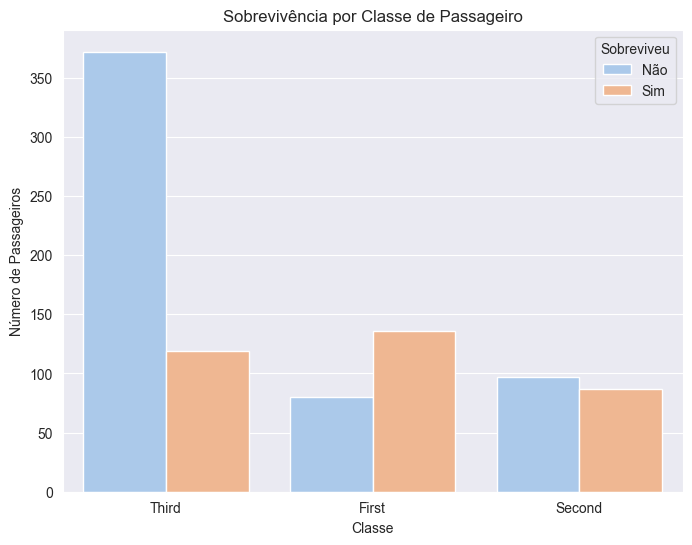

In [108]:
# Sobrevivência por Classe
plt.figure(figsize=(8, 6))
sns.countplot(x='class', hue='survived', data=titanic, palette='pastel')
plt.title('Sobrevivência por Classe de Passageiro')
plt.xlabel('Classe')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

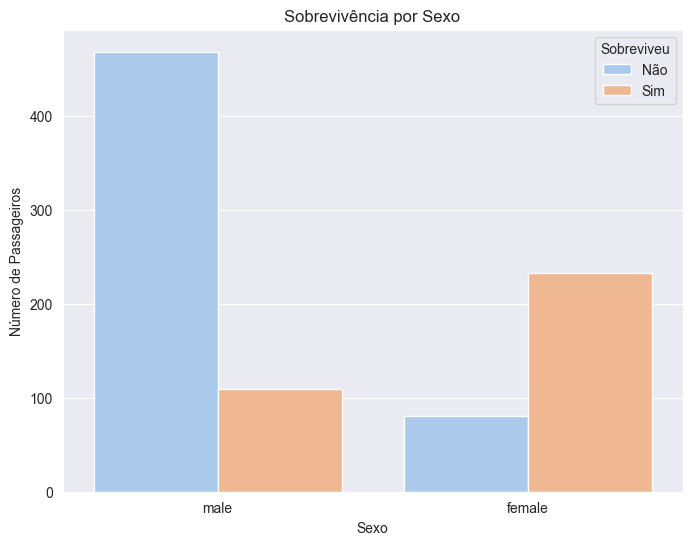

In [109]:
# Sobrevivência por Sexo
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='survived', data=titanic, palette='pastel')
plt.title('Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

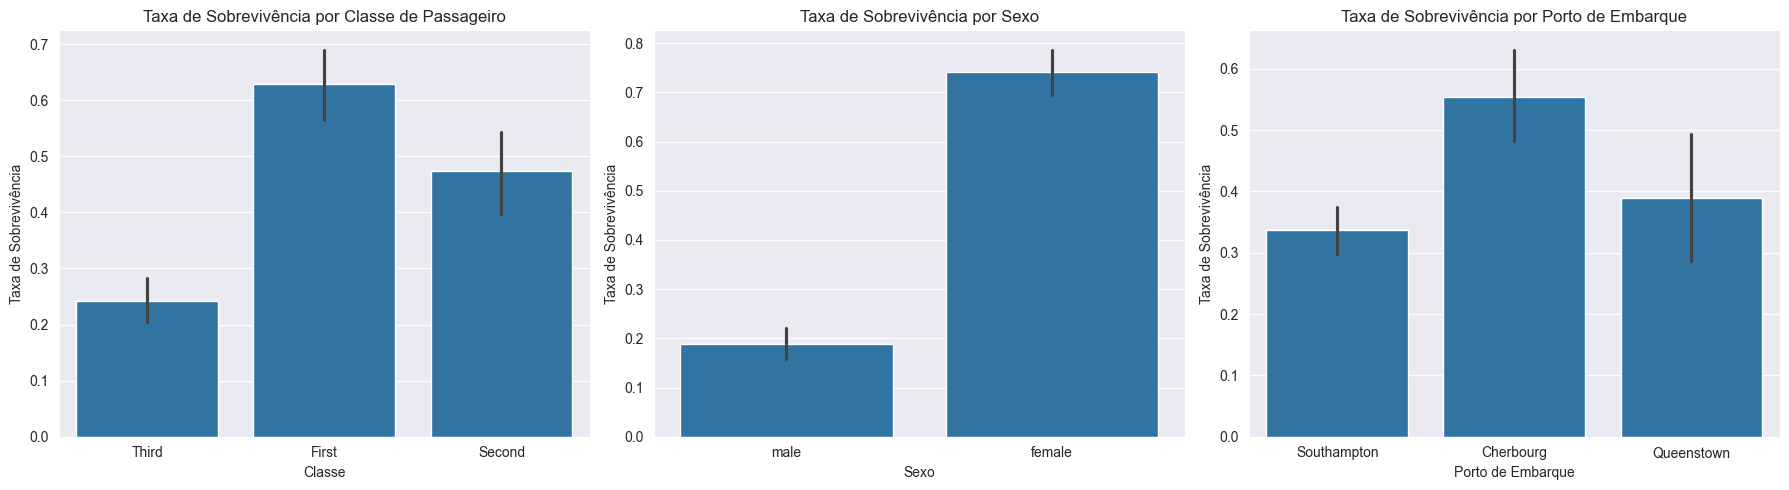

In [110]:
# Análise de proporções de sobrevivência por classe, sexo e porto de embarque
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sobrevivência por Classe
sns.barplot(x='class', y='survived', data=titanic, ax=axes[0])
axes[0].set_title('Taxa de Sobrevivência por Classe de Passageiro')
axes[0].set_ylabel('Taxa de Sobrevivência')
axes[0].set_xlabel('Classe')

# Sobrevivência por Sexo
sns.barplot(x='sex', y='survived', data=titanic, ax=axes[1])
axes[1].set_title('Taxa de Sobrevivência por Sexo')
axes[1].set_ylabel('Taxa de Sobrevivência')
axes[1].set_xlabel('Sexo')

# Sobrevivência por Porto de Embarque
sns.barplot(x='embark_town', y='survived', data=titanic, ax=axes[2])
axes[2].set_title('Taxa de Sobrevivência por Porto de Embarque')
axes[2].set_ylabel('Taxa de Sobrevivência')
axes[2].set_xlabel('Porto de Embarque')

plt.tight_layout()
plt.show()

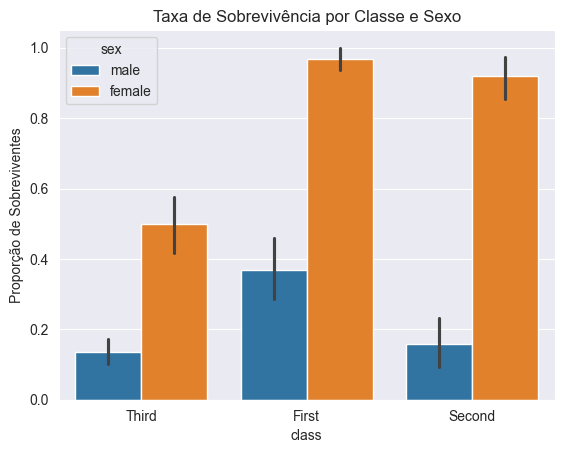

In [111]:
sns.barplot(x='class', y='survived', hue='sex', data=titanic)
plt.title('Taxa de Sobrevivência por Classe e Sexo')
plt.ylabel('Proporção de Sobreviventes')
plt.show()

#### Verificar distribuição dos dados

In [117]:
numericos = titanic.select_dtypes(include=['int', 'float', 'bool'])

In [ ]:
fig, ax = plt.subplots(ncols=len(numericos.columns), nrows=1, figsize=(25, 5))
plt.suptitle("Histogramas dos Atributos Numéricos")

# Histograma para cada atributo numérico
for i in range(0, len(numericos.columns)):
    feature = numericos.columns[i]
    ax[i].set_title(feature)
    numericos[feature].plot(kind='hist', ax=ax[i])

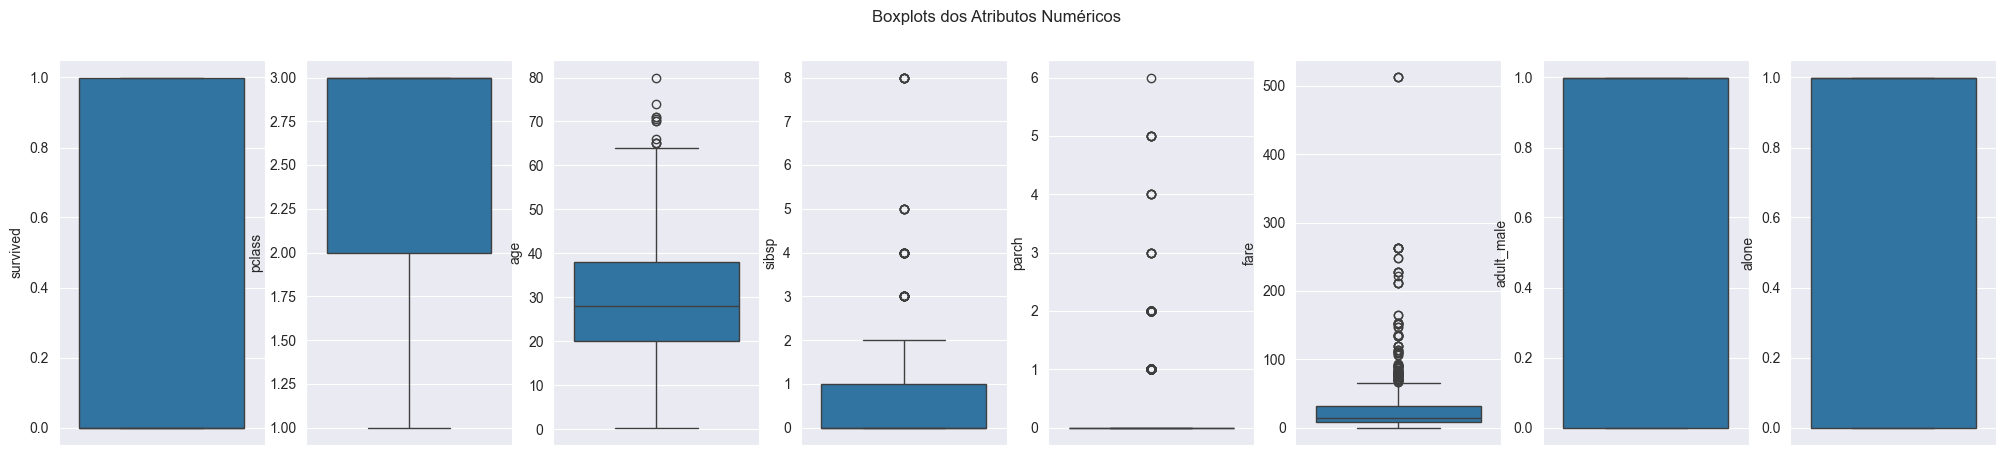

In [119]:
fig, ax = plt.subplots(ncols=len(numericos.columns), nrows=1, figsize=(25, 5))
plt.suptitle("Boxplots dos Atributos Numéricos")

# Gráfico para cada atributo numérico
for i in range(0, len(numericos.columns)):
    feature = numericos.columns[i]
    sns.boxplot(numericos[feature], ax=ax[i], orient='v')